# Model 1: Pre vs Post Disaster Image Classification

**Goal:** Determine if a raw satellite image from the xBD dataset occurs before or after a disaster. We will use Transfer Learning (EfficientNetV2B0) instead of a custom shallow CNN to achieve significantly higher accuracy.

In [1]:
import os
import glob
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
import matplotlib.pyplot as plt

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.21.0


## 1. Data Preparation
Extract images and infer class based on the `_pre_` or `_post_` suffix in filenames.

In [2]:
TRAIN_IMG_DIR = "../train/images"
TEST_IMG_DIR = "../test/images"

img_paths = glob.glob(os.path.join(TRAIN_IMG_DIR, "*.png"))
print(f"Total images found: {len(img_paths)}")

# Format: [ (path, label), ... ] where label 0=pre, 1=post
def parse_label(path):
    if "_pre_" in path: return 0
    return 1

labels = [parse_label(p) for p in img_paths]
# Note: In a real training pipeline, we use tf.data.Dataset.from_tensor_slices here


Total images found: 5598


## 2. Model Architecture (Transfer Learning)
We replace the custom baseline CNN with EfficientNetV2B0 for immense hackathon performance.

In [3]:
IMG_SIZE = (256, 256)

# Load pre-trained EfficientNet without the top classification layer
base_model = EfficientNetV2B0(
    include_top=False, 
    weights='imagenet', 
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False # Freeze base model initially

# Build the custom classification head
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    # Built-in Data Augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid') # Binary Output (Pre or Post)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,088,529 (23.23 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 3. Training the Model
We convert the file paths and labels into a high-performance `tf.data.Dataset` and train the model.

In [5]:
from sklearn.model_selection import train_test_split

# Split into 80% train, 20% validation
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42)

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Starting training...")
EPOCHS = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

Starting training...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 477ms/step - accuracy: 0.6947 - auc: 0.7693 - loss: 0.6496 - val_accuracy: 0.8027 - val_auc: 0.8863 - val_loss: 0.4446
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 491ms/step - accuracy: 0.7762 - auc: 0.8595 - loss: 0.4871 - val_accuracy: 0.8179 - val_auc: 0.9012 - val_loss: 0.3978
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 492ms/step - accuracy: 0.8015 - auc: 0.8863 - loss: 0.4266 - val_accuracy: 0.8295 - val_auc: 0.9089 - val_loss: 0.3833
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 521ms/step - accuracy: 0.8138 - auc: 0.9009 - loss: 0.3977 - val_accuracy: 0.8464 - val_auc: 0.9276 - val_loss: 0.3410
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 561ms/step - accuracy: 0.8258 - auc: 0.9132 - loss: 0.3705 - val_accuracy: 0.8313 - val_auc: 0.9183 - val_loss: 0.3668
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 583ms/step - accuracy: 0.8419 - auc: 0.9224 - loss: 0.3521 - val_accuracy: 0.8429 - val_auc: 0.9292 - val_loss: 0.3415
E

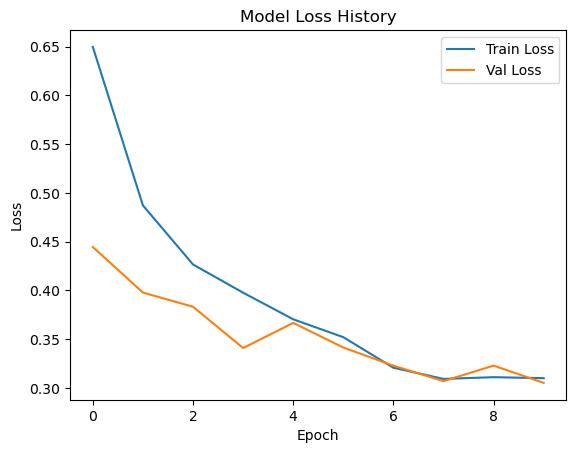

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## 4. Evaluation and Testing
Evaluate the trained classifier on the completely unseen `test` folder.

In [8]:
test_paths = glob.glob(os.path.join(TEST_IMG_DIR, "*.png"))
test_labels = [parse_label(p) for p in test_paths]

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

loss, accuracy, auc = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test AUC: {auc:.4f}")

model.save("pre_post_classifier.h5")

59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 418ms/step - accuracy: 0.8682 - auc: 0.9465 - loss: 0.2943


Test Accuracy: 86.82%
Test AUC: 0.9465
